<a href="https://colab.research.google.com/github/prateekcmr/repo1/blob/main/AutonamosCarUsingRL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training complete! Learned Q-table:
[[-1.51214819 -0.434062   -1.47323708 -0.82353281]
 [-2.11012743  0.5785226  -2.15856606 -1.52662655]
 [-1.71892508  1.60323678 -1.85082646 -1.18247985]
 [-0.94543331  2.64018816 -1.10444273 -1.14577849]
 [-0.74743788 -0.3199029  -0.69361486 -0.77255306]
 [-1.55382636 -1.43347939 -0.51422448  0.62882   ]
 [-1.05858735  0.58199563 -0.54710514  1.8098    ]
 [-0.08219008  2.8086551   0.55012082  3.122     ]
 [ 0.4080243   4.58        1.5699745   3.9862386 ]
 [-0.58286976  6.17756681 -0.16812868  1.94643542]
 [-1.70622321 -1.70321942 -1.73012687  0.74291931]
 [-0.85758217 -1.16975981 -1.20435966  2.93263915]
 [-0.41307347 -0.31876465 -0.37490181  4.57948799]
 [ 2.86350916  5.20234939  2.89402886  6.2       ]
 [ 3.94807966  8.          4.42472535  5.60201091]
 [-1.21833675 -1.21515697 -1.21606577 -1.19855307]
 [-0.74302093 -0.72510476 -0.95901776 -0.40144428]
 [-0.40964779  2.67697339 -0.65455729  0.39811312]
 [ 0.2789      2.64560491  0.17694162  7.93499

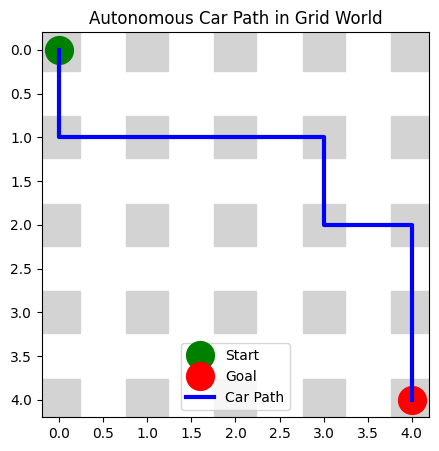

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Environment setup
class AutonomousCarEnv:
    def __init__(self, grid_size=5):
        self.grid_size = grid_size
        self.state_space = grid_size * grid_size
        self.action_space = 4  # up, down, left, right
        self.reset()

    def reset(self):
        self.car_pos = [0, 0]  # start at top-left
        self.goal_pos = [self.grid_size - 1, self.grid_size - 1]  # bottom-right
        return self._get_state()

    def _get_state(self):
        return self.car_pos[0] * self.grid_size + self.car_pos[1]

    def step(self, action):
        if action == 0:  # up
            self.car_pos[0] = max(0, self.car_pos[0] - 1)
        elif action == 1:  # down
            self.car_pos[0] = min(self.grid_size - 1, self.car_pos[0] + 1)
        elif action == 2:  # left
            self.car_pos[1] = max(0, self.car_pos[1] - 1)
        elif action == 3:  # right
            self.car_pos[1] = min(self.grid_size - 1, self.car_pos[1] + 1)

        reward = -1  # small penalty for each move
        done = False
        if self.car_pos == self.goal_pos:
            reward = 10  # reward for reaching destination
            done = True

        return self._get_state(), reward, done

# Q-learning agent
env = AutonomousCarEnv()
q_table = np.zeros((env.state_space, env.action_space))

episodes = 500
alpha = 0.1   # learning rate
gamma = 0.9   # discount factor
epsilon = 0.2 # exploration rate

for episode in range(episodes):
    state = env.reset()
    done = False

    while not done:
        # Exploration vs exploitation
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, env.action_space - 1)
        else:
            action = np.argmax(q_table[state])

        next_state, reward, done = env.step(action)

        # Q-learning update
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state

print("Training complete! Learned Q-table:")
print(q_table)

# Visualization of path after training
state = env.reset()
done = False
path = [env.car_pos.copy()]

while not done:
    action = np.argmax(q_table[state])
    state, reward, done = env.step(action)
    path.append(env.car_pos.copy())

# Plot the grid and path
grid_size = env.grid_size
plt.figure(figsize=(5,5))
for i in range(grid_size):
    for j in range(grid_size):
        plt.plot(j, i, 's', color='lightgrey', markersize=30)

# Mark start and goal
plt.plot(0, 0, 'go', markersize=20, label="Start")
plt.plot(grid_size-1, grid_size-1, 'ro', markersize=20, label="Goal")

# Plot path
path_x = [pos[1] for pos in path]
path_y = [pos[0] for pos in path]
plt.plot(path_x, path_y, 'b-', linewidth=3, label="Car Path")

plt.gca().invert_yaxis()
plt.legend()
plt.title("Autonomous Car Path in Grid World")
plt.show()


Training complete!


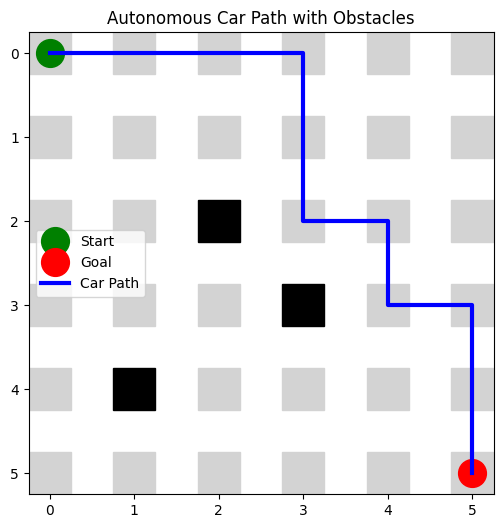

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Environment: 6x6 grid with obstacles
class AutonomousCarEnv:
    def __init__(self, grid_size=6, obstacles=None):
        self.grid_size = grid_size
        self.state_space = grid_size * grid_size
        self.action_space = 4  # up, down, left, right
        self.obstacles = obstacles if obstacles else [[2,2],[3,3],[4,1]]
        self.reset()

    def reset(self):
        self.car_pos = [0, 0]  # start at top-left
        self.goal_pos = [self.grid_size - 1, self.grid_size - 1]  # bottom-right
        return self._get_state()

    def _get_state(self):
        return self.car_pos[0] * self.grid_size + self.car_pos[1]

    def step(self, action):
        if action == 0:  # up
            self.car_pos[0] = max(0, self.car_pos[0] - 1)
        elif action == 1:  # down
            self.car_pos[0] = min(self.grid_size - 1, self.car_pos[0] + 1)
        elif action == 2:  # left
            self.car_pos[1] = max(0, self.car_pos[1] - 1)
        elif action == 3:  # right
            self.car_pos[1] = min(self.grid_size - 1, self.car_pos[1] + 1)

        reward = -1
        done = False
        if self.car_pos in self.obstacles:
            reward = -100
            done = True
        elif self.car_pos == self.goal_pos:
            reward = 50
            done = True

        return self._get_state(), reward, done

# Q-learning agent
env = AutonomousCarEnv()
q_table = np.zeros((env.state_space, env.action_space))

episodes = 1000
alpha = 0.1
gamma = 0.9
epsilon = 0.2

for episode in range(episodes):
    state = env.reset()
    done = False
    while not done:
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, env.action_space - 1)
        else:
            action = np.argmax(q_table[state])
        next_state, reward, done = env.step(action)
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )
        state = next_state

print("Training complete!")

# Visualize learned path
state = env.reset()
done = False
path = [env.car_pos.copy()]
while not done:
    action = np.argmax(q_table[state])
    state, reward, done = env.step(action)
    path.append(env.car_pos.copy())

# Animate path
fig, ax = plt.subplots(figsize=(6,6))
for i in range(env.grid_size):
    for j in range(env.grid_size):
        if [i,j] in env.obstacles:
            ax.plot(j, i, 'ks', markersize=30)  # obstacle
        else:
            ax.plot(j, i, 's', color='lightgrey', markersize=30)

ax.plot(0, 0, 'go', markersize=20, label="Start")
ax.plot(env.grid_size-1, env.grid_size-1, 'ro', markersize=20, label="Goal")

path_x = [pos[1] for pos in path]
path_y = [pos[0] for pos in path]
ax.plot(path_x, path_y, 'b-', linewidth=3, label="Car Path")

ax.invert_yaxis()
ax.legend()
ax.set_title("Autonomous Car Path with Obstacles")
plt.show()


Training complete!


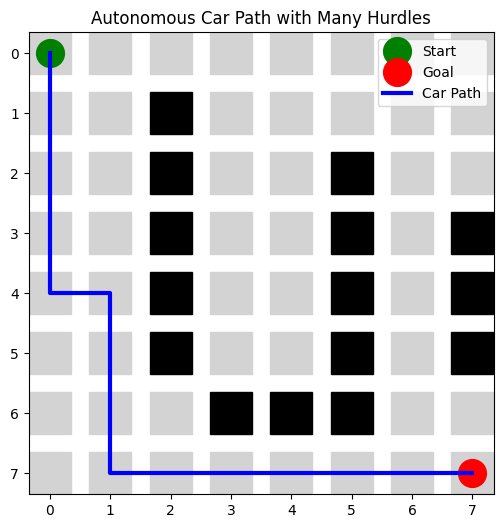

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Environment: 8x8 grid with many obstacles
class AutonomousCarEnv:
    def __init__(self, grid_size=8, obstacles=None):
        self.grid_size = grid_size
        self.state_space = grid_size * grid_size
        self.action_space = 4  # up, down, left, right
        # Default obstacles scattered across the grid
        self.obstacles = obstacles if obstacles else [
            [1,2],[2,2],[3,2],[4,2],[5,2],
            [2,5],[3,5],[4,5],[5,5],
            [6,3],[6,4],[6,5],
            [3,7],[4,7],[5,7]
        ]
        self.reset()

    def reset(self):
        self.car_pos = [0, 0]  # start at top-left
        self.goal_pos = [self.grid_size - 1, self.grid_size - 1]  # bottom-right
        return self._get_state()

    def _get_state(self):
        return self.car_pos[0] * self.grid_size + self.car_pos[1]

    def step(self, action):
        if action == 0:  # up
            self.car_pos[0] = max(0, self.car_pos[0] - 1)
        elif action == 1:  # down
            self.car_pos[0] = min(self.grid_size - 1, self.car_pos[0] + 1)
        elif action == 2:  # left
            self.car_pos[1] = max(0, self.car_pos[1] - 1)
        elif action == 3:  # right
            self.car_pos[1] = min(self.grid_size - 1, self.car_pos[1] + 1)

        reward = -1
        done = False
        if self.car_pos in self.obstacles:
            reward = -50
            done = True
        elif self.car_pos == self.goal_pos:
            reward = 100
            done = True

        return self._get_state(), reward, done

# Q-learning agent
env = AutonomousCarEnv()
q_table = np.zeros((env.state_space, env.action_space))

episodes = 2000
alpha = 0.1
gamma = 0.9
epsilon = 0.2

for episode in range(episodes):
    state = env.reset()
    done = False
    while not done:
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, env.action_space - 1)
        else:
            action = np.argmax(q_table[state])
        next_state, reward, done = env.step(action)
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )
        state = next_state

print("Training complete!")

# Visualize learned path
state = env.reset()
done = False
path = [env.car_pos.copy()]
while not done:
    action = np.argmax(q_table[state])
    state, reward, done = env.step(action)
    path.append(env.car_pos.copy())

# Plot grid with obstacles and path
grid_size = env.grid_size
plt.figure(figsize=(6,6))
for i in range(grid_size):
    for j in range(grid_size):
        if [i,j] in env.obstacles:
            plt.plot(j, i, 'ks', markersize=30)  # obstacle
        else:
            plt.plot(j, i, 's', color='lightgrey', markersize=30)

plt.plot(0, 0, 'go', markersize=20, label="Start")
plt.plot(grid_size-1, grid_size-1, 'ro', markersize=20, label="Goal")

path_x = [pos[1] for pos in path]
path_y = [pos[0] for pos in path]
plt.plot(path_x, path_y, 'b-', linewidth=3, label="Car Path")

plt.gca().invert_yaxis()
plt.legend()
plt.title("Autonomous Car Path with Many Hurdles")
plt.show()


Training complete!


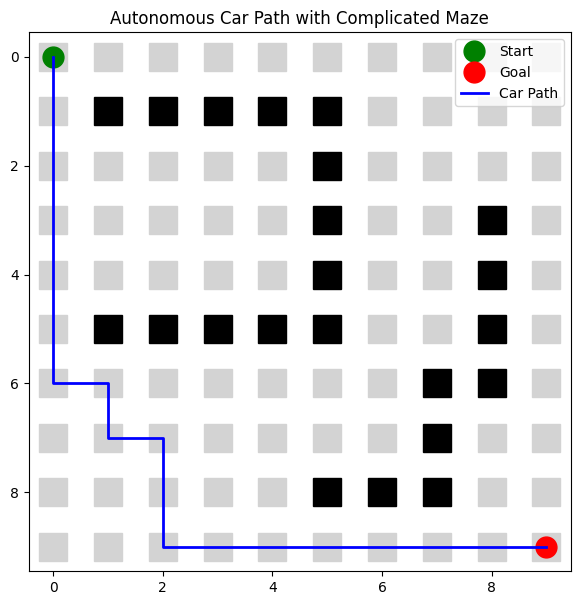

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Environment: 10x10 grid with complex obstacles
class AutonomousCarEnv:
    def __init__(self, grid_size=10, obstacles=None):
        self.grid_size = grid_size
        self.state_space = grid_size * grid_size
        self.action_space = 4  # up, down, left, right
        # Maze-like obstacles
        self.obstacles = obstacles if obstacles else [
            [1,1],[1,2],[1,3],[1,4],[1,5],
            [2,5],[3,5],[4,5],[5,5],
            [5,1],[5,2],[5,3],[5,4],
            [6,7],[7,7],[8,7],[8,6],[8,5],
            [3,8],[4,8],[5,8],[6,8]
        ]
        self.reset()

    def reset(self):
        self.car_pos = [0, 0]  # start at top-left
        self.goal_pos = [self.grid_size - 1, self.grid_size - 1]  # bottom-right
        return self._get_state()

    def _get_state(self):
        return self.car_pos[0] * self.grid_size + self.car_pos[1]

    def step(self, action):
        if action == 0:  # up
            self.car_pos[0] = max(0, self.car_pos[0] - 1)
        elif action == 1:  # down
            self.car_pos[0] = min(self.grid_size - 1, self.car_pos[0] + 1)
        elif action == 2:  # left
            self.car_pos[1] = max(0, self.car_pos[1] - 1)
        elif action == 3:  # right
            self.car_pos[1] = min(self.grid_size - 1, self.car_pos[1] + 1)

        reward = -1
        done = False
        if self.car_pos in self.obstacles:
            reward = -100
            done = True
        elif self.car_pos == self.goal_pos:
            reward = 200
            done = True

        return self._get_state(), reward, done

# Q-learning agent
env = AutonomousCarEnv()
q_table = np.zeros((env.state_space, env.action_space))

episodes = 3000
alpha = 0.1
gamma = 0.9
epsilon = 0.2

for episode in range(episodes):
    state = env.reset()
    done = False
    while not done:
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, env.action_space - 1)
        else:
            action = np.argmax(q_table[state])
        next_state, reward, done = env.step(action)
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )
        state = next_state

print("Training complete!")

# Visualize learned path
state = env.reset()
done = False
path = [env.car_pos.copy()]
while not done:
    action = np.argmax(q_table[state])
    state, reward, done = env.step(action)
    path.append(env.car_pos.copy())

# Plot grid with obstacles and path
grid_size = env.grid_size
plt.figure(figsize=(7,7))
for i in range(grid_size):
    for j in range(grid_size):
        if [i,j] in env.obstacles:
            plt.plot(j, i, 'ks', markersize=20)  # obstacle
        else:
            plt.plot(j, i, 's', color='lightgrey', markersize=20)

plt.plot(0, 0, 'go', markersize=15, label="Start")
plt.plot(grid_size-1, grid_size-1, 'ro', markersize=15, label="Goal")

path_x = [pos[1] for pos in path]
path_y = [pos[0] for pos in path]
plt.plot(path_x, path_y, 'b-', linewidth=2, label="Car Path")

plt.gca().invert_yaxis()
plt.legend()
plt.title("Autonomous Car Path with Complicated Maze")
plt.show()
